# Book catalog web search - conversion estimation for each search mechanism nanananan

Compare how successful is the conversion rate via search vs. filtering the results via the category option. 
- Investigate how both scenarios are reflected in provided web analytics data.
- Suggest a definition of conversion rate metric.
- Perform analysis in any language (please share the code with us).
- Prepare a very brief presentation of results. Debate over them will take place in a face-to-face meeting on-site. A very simple visualization/table in any form (notebook, dashboard, written document) will suffice.

In [ ]:
import pandas as pd
import json
import plotly.express as px
import numpy as np
from math import sqrt

/Users/amiolla/.pyenv/versions/3.8.20/envs/global_env/lib/python3.8/site-packages/pandas/compat/__init__.py:124: UserWarning: Could not import the lzma module. Your installed Python is incomplete. Attempting to use lzma compression will result in a RuntimeError.
  warnings.warn(msg)


## EDA

In [2]:
df = pd.read_csv('assignment_data')
print(df.shape)
df.head()

(3360867, 5)


,event_name,user_pseudo_id,fe_timestamp,domain,event_params
0,view_item,1.264383e+09,1735548034750,DE,"[{""key"":""engagement_time_msec"",""value"":{""strin..."
1,view_item,7.831363e+08,1735733813350,DE,"[{""key"":""ga_session_id"",""value"":{""string_value..."
2,view_item,5.665565e+07,1735760081411,DE,"[{""key"":""user_supplier_count"",""value"":{""string..."
3,view_item,1.222321e+09,1735682099391,DE,"[{""key"":""value"",""value"":{""string_value"":null,""..."
4,view_item,1.992516e+09,1735682549117,DE,"[{""key"":""currency"",""value"":{""string_value"":""EU..."


In [3]:
# Check data types
df.dtypes

event_name         object
user_pseudo_id    float64
fe_timestamp        int64
domain             object
event_params       object
dtype: object

In [4]:
# Check event type
df['event_name'].value_counts(normalize=True)

page_view                             0.451206
view_item                             0.135079
ux_site_search_suggestions            0.124126
session_start                         0.109996
ux_site_search_input_focus            0.087755
ux_site_search_submit_input_press     0.022925
view_cart                             0.020271
add_to_cart                           0.017082
ux_site_search_suggestion_click       0.013344
ux_site_search_empty_suggestions      0.009683
ux_site_search_submit_button_click    0.005972
purchase                              0.002551
view_search_results                   0.000011
Name: event_name, dtype: float64

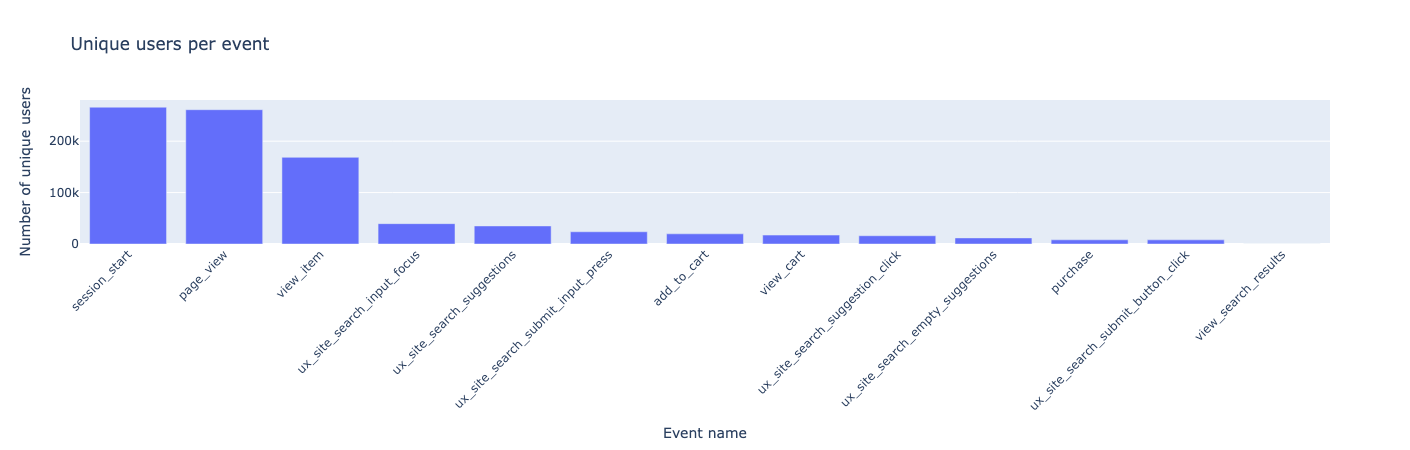

In [37]:
# Number of unique users per event_name
unique_users_per_event = (df.groupby("event_name")["user_pseudo_id"].nunique().reset_index(name="unique_users"))

# Sort by number of users (descending)
unique_users_per_event = unique_users_per_event.sort_values(by="unique_users", ascending=False)

# Plot sorted bar chart with Plotly
fig = px.bar(
    unique_users_per_event,
    x="event_name",
    y="unique_users",
    title="Unique users per event",
    labels={
        "event_name": "Event name",
        "unique_users": "Number of unique users"
    }
)

fig.update_layout(
    xaxis_tickangle=-45,
    height=450
)

fig.show()

These results show that almost all users **start a session** (266k session_start) and **view pages** (261k page_view), while a smaller but still substantial group views **product pages** (168k view_item), indicating strong browsing activity.

**Search behavior** is widespread: around 40k users interact with the search bar (search input focus), and many receive or interact with suggestions, confirming that search is an important discovery mechanism. Fewer users complete a search action (e.g., submit or click a suggestion), probably indicating that exploratory or abandoned searches are common or the suggestions do not match the expectation of the customers.

As expected, **conversion events** involve fewer users: about 19.7k **add to cart** and 8.1k **purchases**, reflecting a typical e-commerce funnel drop-off. The very low count of **view_search_results** indicates that most product discovery happens directly via suggestions or navigation rather than a dedicated results page.

In [6]:
# Remove unnecessary col
df = df.drop(['domain'], axis= 1) # no need since it has only one string DE (explored before with value_counts)
df.shape

(3360867, 4)

In [7]:
# Convert the timestamp in a different format to be more readable
df["fe_timestamp"] = (
    pd.to_datetime(df["fe_timestamp"], unit="ms", utc=True)
      .dt.tz_convert("Europe/Prague")  # change as needed
)

df.head(3)

,event_name,user_pseudo_id,fe_timestamp,event_params
0,view_item,1.264383e+09,2024-12-30 09:40:34.750000+01:00,"[{""key"":""engagement_time_msec"",""value"":{""strin..."
1,view_item,7.831363e+08,2025-01-01 13:16:53.350000+01:00,"[{""key"":""ga_session_id"",""value"":{""string_value..."
2,view_item,5.665565e+07,2025-01-01 20:34:41.411000+01:00,"[{""key"":""user_supplier_count"",""value"":{""string..."


In [8]:
# Extract key info from event_params [# pd.set_option("display.max_colwidth", None)]
keys_to_extract = [
    "ga_session_id",
    "engagement_time_msec",
    "value",
    "page_title",
    "page_location"
]


def extract_event_params(param_str, keys):
    params = json.loads(param_str)
    out = {}

    for p in params:
        key = p["key"]
        if key in keys:
            value_dict = p["value"]
            # pick the non-null value
            value = next(
                (v for v in value_dict.values() if v is not None),
                None
            )
            out[key] = value

    return out

In [9]:
extracted = df["event_params"].apply(
    lambda x: extract_event_params(x, keys_to_extract)
)

extracted_df = pd.DataFrame(extracted.tolist())
df = pd.concat([df.drop(columns=["event_params"]), extracted_df], axis=1)
print(df.shape)
df.head()

(3360867, 8)


,event_name,user_pseudo_id,fe_timestamp,engagement_time_msec,value,page_title,ga_session_id,page_location
0,view_item,1.264383e+09,2024-12-30 09:40:34.750000+01:00,220.0,6.23,Attracted - Anna Todd - bookbot.de,1735547698,https://bookbot.de/g/724739/b/10376492?fallbac...
1,view_item,7.831363e+08,2025-01-01 13:16:53.350000+01:00,NaN,1.64,As I Walked Out One Midsummer Morning - Laurie...,1735727079,https://bookbot.de/g/3573327/b/8102151
2,view_item,5.665565e+07,2025-01-01 20:34:41.411000+01:00,90.0,19.40,Nietzsche. Werke in vier Bänden - Friedrich Ni...,1735758548,https://bookbot.de/g/7943114/b/10553284
3,view_item,1.222321e+09,2024-12-31 22:54:59.391000+01:00,14.0,10.98,Der Heimweg - Sebastian Fitzek - bookbot.de,1735682100,https://bookbot.de/g/587288/b/10552865
4,view_item,1.992516e+09,2024-12-31 23:02:29.117000+01:00,NaN,1.94,Ein Herzschlag danach - Sarah Alderson - bookb...,1735682012,https://bookbot.de/g/3112425?xnpe_tifc=bdeu4kY...


Range date goes from 2024-11-10 to 2025-01-24


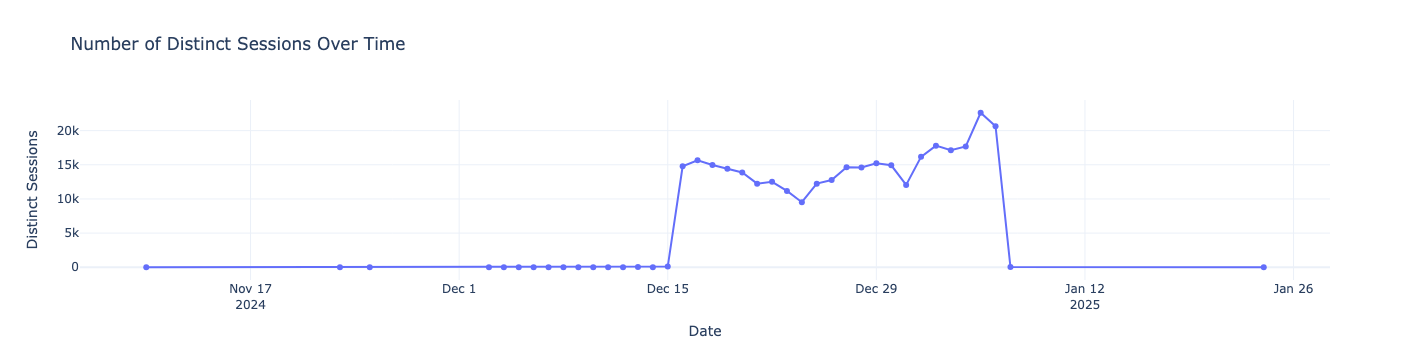

In [38]:
# Create a new column for the day 
df["date"] = df["fe_timestamp"].dt.date  # daily aggregation
print('Range date goes from', min(df["date"]), 'to', max(df["date"]))

# Count distinct sessions per day
sessions_per_day = df.groupby("date")["ga_session_id"].nunique().reset_index()
sessions_per_day = sessions_per_day.rename(columns={"ga_session_id": "distinct_sessions"})

# Plot with Plotly
fig = px.line(
    sessions_per_day,
    x="date",
    y="distinct_sessions",
    title="Number of Distinct Sessions Over Time",
    markers=True
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Distinct Sessions",
    template="plotly_white"
)

fig.show()

The distribution indicates a clear seasonality effect, with a peak in sessions around the Christmas period.

In [11]:
# Check NaN of new cols
# --- 1. Calculate percentage of missing values ---
missing_pct = df.isna().mean() * 100
missing_pct = missing_pct.round(2)  # round to 2 decimals

# Convert to DataFrame for plotting
missing_df = missing_pct.reset_index()
missing_df.columns = ["column", "missing_percent"]
missing_df = missing_df.sort_values("missing_percent", ascending=False)
missing_df

,column,missing_percent
3,engagement_time_msec,84.36
4,value,82.50
5,page_title,71.51
0,event_name,0.00
1,user_pseudo_id,0.00
2,fe_timestamp,0.00
6,ga_session_id,0.00
7,page_location,0.00
8,date,0.00


In [12]:
# Check event names where title is not null
df.loc[df['page_title'].notna(), 'event_name'].unique()

array(['view_item', 'add_to_cart', 'session_start', 'purchase',
       'view_cart', 'view_search_results'], dtype=object)

Engagement time (ms) and **monetary value** could also be used as proxies to determine 
which mechanism drives higher engagement or generates more revenue, in combination 
with the **conversion rate**. However, due to the percentage of missing values and the 
time constraints for this use case, this is considered a **potential future direction**.

The **book title** was initially considered to link search queries to conversions, but since it is unclear how conversions are attributed to specific events and about 71.5% of titles are missing, it was not used.

In [13]:
# Remove extra cols not needed for the definition of conversion (defined later in the notebook)
df = df.drop(columns=['engagement_time_msec', 'value', 'page_title', 'date'])
print(df.shape)
df.head(3)

(3360867, 5)


,event_name,user_pseudo_id,fe_timestamp,ga_session_id,page_location
0,view_item,1.264383e+09,2024-12-30 09:40:34.750000+01:00,1735547698,https://bookbot.de/g/724739/b/10376492?fallbac...
1,view_item,7.831363e+08,2025-01-01 13:16:53.350000+01:00,1735727079,https://bookbot.de/g/3573327/b/8102151
2,view_item,5.665565e+07,2025-01-01 20:34:41.411000+01:00,1735758548,https://bookbot.de/g/7943114/b/10553284


In [14]:
# Convert id fields to string
df['user_pseudo_id'] = df['user_pseudo_id'].astype(str)
df['ga_session_id'] = df['ga_session_id'].astype(str)
df.dtypes

event_name                               object
user_pseudo_id                           object
fe_timestamp      datetime64[ns, Europe/Prague]
ga_session_id                            object
page_location                            object
dtype: object

In [15]:
# Check unique users based on the pseudo_id
df['user_pseudo_id'].nunique()

266199

In [16]:
# Check unique sessions
df['ga_session_id'].nunique()

326529

In [17]:
# Count unique sessions per user
sessions_per_user = df.groupby("user_pseudo_id")["ga_session_id"].nunique()

one_session = (sessions_per_user == 1).sum()
multiple_sessions = (sessions_per_user > 1).sum()
total_users = sessions_per_user.shape[0]

pct_one_session = one_session / total_users * 100
pct_multiple_sessions = multiple_sessions / total_users * 100

print(f"Users with 1 session: {pct_one_session:.1f}%")
print(f"Users with multiple sessions: {pct_multiple_sessions:.1f}%")

Users with 1 session: 85.4%
Users with multiple sessions: 14.6%


Max number of sessions obtained by an user is:  271


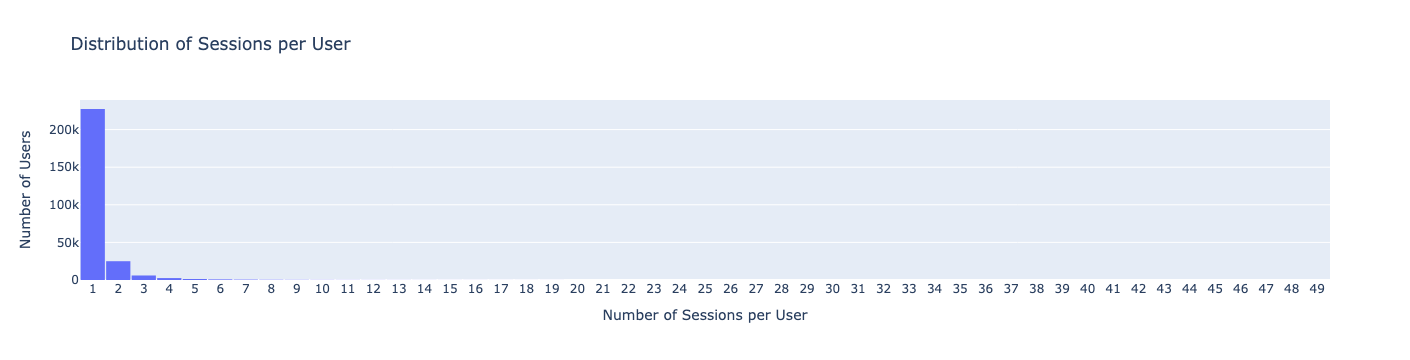

In [39]:
# Compute number of sessions per user
sessions_per_user = df.groupby("user_pseudo_id")["ga_session_id"].nunique().reset_index(name="n_sessions")
print('Max number of sessions obtained by an user is: ', max(sessions_per_user['n_sessions']))
sessions_per_user_filt = sessions_per_user[sessions_per_user['n_sessions'] < 50]

# Plot histogram
fig = px.histogram(
    sessions_per_user_filt,
    x="n_sessions",
    nbins=50,
    title="Distribution of Sessions per User",
    labels={"n_sessions": "Number of Sessions per User"}
)

fig.update_layout(
    xaxis=dict(dtick=1),  # show integer ticks
    yaxis_title="Number of Users",
    bargap=0.05
)

fig.show()

The histogram was truncated to clearly show the skewness of the results. About **14.6%** of users have multiple sessions, and some outliers have more than 50 sessions (up to 271). To avoid inflating or biasing the conversion rate (i.e., since multiple sessions from the same user can artificially increase the denominator) the conversion rate will be calculated at the user level. This approach mitigates **session-level bias** caused by highly active users.

## USER EXPOSURE APPROACH

**Conversion rate** is calculated at the **user level** to avoid biases from multiple sessions. **Conversion** is linked to **whether a user was exposed to search or category filtering at any point in their journey**.
This method evaluates whether users who were exposed to search or category filtering (browse) are more likely to convert overall.

Each user is flagged based on whether they ever used search, ever used category filtering, and whether they completed at least one conversion event (view_item, add_to_cart, purchase). **Users may be associated with one or both mechanisms, and conversions are counted for all mechanisms the user was exposed to**. 

At the user level:
- **Denominator**: number of users who were exposed to the mechanism (i.e., users who used search or category filtering at least once).
- **Numerator**: number of users who completed at least one conversion after being exposed to that mechanism.

From these, the user-level conversion rates are computed as:
- **View item rate: %** of users exposed to the mechanism who viewed at least one item.
- **Add-to-cart rate: %** of users who added at least one item to the cart after viewing an item.
- **Purchase rate: %** of users who completed at least one purchase after viewing an item.

In [19]:
df.head(3)

,event_name,user_pseudo_id,fe_timestamp,ga_session_id,page_location
0,view_item,1264382950.173555,2024-12-30 09:40:34.750000+01:00,1735547698,https://bookbot.de/g/724739/b/10376492?fallbac...
1,view_item,783136260.1735661,2025-01-01 13:16:53.350000+01:00,1735727079,https://bookbot.de/g/3573327/b/8102151
2,view_item,56655646.173575856,2025-01-01 20:34:41.411000+01:00,1735758548,https://bookbot.de/g/7943114/b/10553284


In [20]:
search_events = {
    "ux_site_search_input_focus",
    "ux_site_search_submit_input_press",
    "ux_site_search_submit_button_click",
    "ux_site_search_suggestions",
    "ux_site_search_suggestion_click",
    "view_search_results"
}

# Categorization search vs filter research mechanism
df["is_search"] = df["event_name"].isin(search_events)
df["is_filter"] = df["page_location"].str.contains("category", case=False, na=False) # based on Slack message, it indicates if user used 'filter' option

In [21]:
# Flag conversion-relevant events
df["view_item_flag"] = df["event_name"] == "view_item"
df["added_to_cart"] = df["event_name"] == "add_to_cart"
df["purchased"] = df["event_name"] == "purchase"

In [22]:
# Group by users and assign conversion to both methods if both are used
user_flags = df.groupby("user_pseudo_id").agg(
    used_search=("is_search", "max"),
    used_filter=("is_filter", "max"),
    viewed_item=("view_item_flag", "max"),
    added_to_cart=("added_to_cart", "max"),
    purchased=("purchased", "max")
).reset_index()

print(user_flags.shape)
user_flags.head(3)

(266199, 6)


,user_pseudo_id,used_search,used_filter,viewed_item,added_to_cart,purchased
0,100000145.17361207,False,False,False,False,False
1,1000005316.17353,False,False,False,False,False
2,1000007822.1734875,False,False,True,False,False


In [23]:
# Define user groups for the calculation of conversion metrics
search_users = user_flags[user_flags["used_search"] == 1]
filter_users = user_flags[user_flags["used_filter"] == 1]

# Pure browsing: no search, no filter
browse_users = user_flags[
    (user_flags["used_search"] == 0) &
    (user_flags["used_filter"] == 0)
]

In [24]:
# Function for the calculation of conversion rates
def compute_rates(df):
    view_rate = df["viewed_item"].mean() * 100
    
    cart_rate = (
        df["added_to_cart"].sum() / df["viewed_item"].sum()
        if df["viewed_item"].sum() > 0 else 0
    ) * 100
    
    purchase_rate = (
        df["purchased"].sum() / df["viewed_item"].sum()
        if df["viewed_item"].sum() > 0 else 0
    ) * 100
    
    return round(view_rate, 2), round(cart_rate, 2), round(purchase_rate, 2)

search_view, search_cart, search_purchase = compute_rates(search_users)
filter_view, filter_cart, filter_purchase = compute_rates(filter_users)
browse_view, browse_cart, browse_purchase = compute_rates(browse_users)

In [25]:
# Build final summary table
summary = pd.DataFrame({
    "mechanism": ["search", "filter", "browse"],
    "users": [
        len(search_users),
        len(filter_users),
        len(browse_users)
    ],
    "total_view_item": [
        search_users["viewed_item"].sum(),
        filter_users["viewed_item"].sum(),
        browse_users["viewed_item"].sum()
    ],
    "total_add_to_cart": [
        search_users["added_to_cart"].sum(),
        filter_users["added_to_cart"].sum(),
        browse_users["added_to_cart"].sum()
    ],
    "total_purchase": [
        search_users["purchased"].sum(),
        filter_users["purchased"].sum(),
        browse_users["purchased"].sum()
    ],
    "view_item_rate %": [
        search_view,
        filter_view,
        browse_view
    ],
    "add_to_cart_rate %": [
        search_cart,
        filter_cart,
        browse_cart
    ],
    "purchase_rate %": [
        search_purchase,
        filter_purchase,
        browse_purchase
    ]
})

summary

,mechanism,users,total_view_item,total_add_to_cart,total_purchase,view_item_rate %,add_to_cart_rate %,purchase_rate %
0,search,40057,25786,10472,4196,64.37,40.61,16.27
1,filter,16228,9782,4392,1612,60.28,44.90,16.48
2,browse,218098,139713,8435,3695,64.06,6.04,2.64


Users that used **Search** and **filter** behaviours show significantly stronger conversion than users who were pure **browsing**. While the **view item rate** is similar across all mechanisms (around 60–64%), the downstream conversion metrics diverge sharply. Users that used **search** and **category filtering** are far **more likely to add items to the cart and complete a purchase** than users who only browse without using any discovery mechanism.

As expected, pure **browsing users** convert poorly, with a very low add-to-cart and purchase rate, highlighting that without structured discovery tools (search or filters) or clear intentions to buy, users are much less likely to progress toward conversion. 

However, **these results** reflect overall conversion behavior among users exposed to each mechanism, but they **cannot be interpreted causally** (i.e., we cannot conclude that using filters or search directly causes more conversions) **since users may be counted in multiple mechanisms** and conversions are aggregated. Thus, it is better to conclude saying that users who adopted search and filter bahviours are more likely to convert compared to users who adopted pure browsing behaviours during their research.

## LAST ATTRIBUTION APPROACH

**Conversion rate** is calculated at the **user level** to avoid biases from multiple sessions. Each conversion event (**view_item**, **add_to_cart**, **purchase**) is attributed to the **last mechanism** the user engaged with before the conversion (either **search** or **browsing**). Users who did not perform a relevant action (or event name) before a conversion are **excluded** from mechanism-level calculations since it is not possible to attribute the bhaviour that led to the conversion. If it is not possible to assign any search or browsing mechanism before the conversion, the user is removed to keep the results as accurate as possible (even if it means reducing the amount of data and do not reflect the 'entropic' behaviour of the customers).

At the **user level**:

- **Denominator:** number of users who actually used the 'research mechanism' (i.e., **search** or **browse**).  
- **Numerator:** number of users who completed at least one conversion within that mechanism.  

From these, the **user-level conversion rates** are computed as:

- **View item rate:** % of users in the mechanism who viewed at least one item.  
- **Add-to-cart rate:** % of users who added to cart after viewing an item.  
- **Purchase rate:** % of users who purchased after viewing an item.  

In [26]:
# Event names under the definition of "search" mechanism
search_events = {
    "ux_site_search_input_focus",
    "ux_site_search_submit_input_press",
    "ux_site_search_submit_button_click",
    "ux_site_search_suggestions",
    "ux_site_search_suggestion_click",
    "view_search_results"
}

df["is_filter"] = df["page_location"].str.contains("category", case=False, na=False) # based on Slack message, it indicates if user used 'filter' option
df["is_search"] = df["event_name"].isin(search_events)
df.head()

,event_name,user_pseudo_id,fe_timestamp,ga_session_id,page_location,is_search,is_filter,view_item_flag,added_to_cart,purchased
0,view_item,1264382950.173555,2024-12-30 09:40:34.750000+01:00,1735547698,https://bookbot.de/g/724739/b/10376492?fallbac...,False,False,True,False,False
1,view_item,783136260.1735661,2025-01-01 13:16:53.350000+01:00,1735727079,https://bookbot.de/g/3573327/b/8102151,False,False,True,False,False
2,view_item,56655646.173575856,2025-01-01 20:34:41.411000+01:00,1735758548,https://bookbot.de/g/7943114/b/10553284,False,False,True,False,False
3,view_item,1222320762.1735678,2024-12-31 22:54:59.391000+01:00,1735682100,https://bookbot.de/g/587288/b/10552865,False,False,True,False,False
4,view_item,1992515808.173568,2024-12-31 23:02:29.117000+01:00,1735682012,https://bookbot.de/g/3112425?xnpe_tifc=bdeu4kY...,False,False,True,False,False


In [27]:
# Flag conversion-relevant events
df["view_item_flag"] = df["event_name"] == "view_item"
df["added_to_cart"] = df["event_name"] == "add_to_cart"
df["purchased"] = df["event_name"] == "purchase"
df.head()

,event_name,user_pseudo_id,fe_timestamp,ga_session_id,page_location,is_search,is_filter,view_item_flag,added_to_cart,purchased
0,view_item,1264382950.173555,2024-12-30 09:40:34.750000+01:00,1735547698,https://bookbot.de/g/724739/b/10376492?fallbac...,False,False,True,False,False
1,view_item,783136260.1735661,2025-01-01 13:16:53.350000+01:00,1735727079,https://bookbot.de/g/3573327/b/8102151,False,False,True,False,False
2,view_item,56655646.173575856,2025-01-01 20:34:41.411000+01:00,1735758548,https://bookbot.de/g/7943114/b/10553284,False,False,True,False,False
3,view_item,1222320762.1735678,2024-12-31 22:54:59.391000+01:00,1735682100,https://bookbot.de/g/587288/b/10552865,False,False,True,False,False
4,view_item,1992515808.173568,2024-12-31 23:02:29.117000+01:00,1735682012,https://bookbot.de/g/3112425?xnpe_tifc=bdeu4kY...,False,False,True,False,False


In [28]:
# the Conversion will be assigned to the last activity (browsing or searching) before the conversion
df = df.sort_values(["ga_session_id", "fe_timestamp"]) 

def get_last_mechanism(row, session_df):
    """
    Returns 'search' if the last relevant event was search,
    'browse' if the last relevant event was filtered browse,
    None if no relevant activity in session.
    """
    # Include the current event in the search/filter check
    relevant_events = session_df[
        (session_df["fe_timestamp"] <= row["fe_timestamp"]) & 
        (session_df["is_search"] | session_df["is_filter"])
    ]
    
    if relevant_events.empty:
        return None  # no relevant activity in session
    
    last_event = relevant_events.iloc[-1]
    if last_event["is_search"]:
        return "search"
    else:
        return "filter"

In [29]:
# Events considered for the conversion
conversions = df[df["view_item_flag"] | df["added_to_cart"] | df["purchased"]].copy()

# Group by session for efficiency
grouped_sessions = df.groupby("ga_session_id")

# Apply last mechanism attribution
conversions["mechanism"] = conversions.apply(
    lambda row: get_last_mechanism(row, grouped_sessions.get_group(row["ga_session_id"])),
    axis=1
)

In [30]:
# Keep only conversions where we can assign a mechanism to not inflate number of users who browse or search
conversions = conversions[conversions["mechanism"].notna()]
print(conversions.shape)
conversions.head(3)

(217763, 11)


,event_name,user_pseudo_id,fe_timestamp,ga_session_id,page_location,is_search,is_filter,view_item_flag,added_to_cart,purchased,mechanism
2617567,view_item,720485889.1734113,2024-12-13 22:14:54.176000+01:00,1734123770,https://bookbot.de/g/3769411,False,False,True,False,False,search
2977064,view_item,720485889.1734113,2024-12-13 22:17:40.715000+01:00,1734123770,https://bookbot.de/g/3523367/b/10309370,False,False,True,False,False,search
2782133,view_item,720485889.1734113,2024-12-13 22:21:38.610000+01:00,1734123770,https://bookbot.de/g/3523367/b/10309370,False,False,True,False,False,search


In [31]:
# Get df with Users having conversions in one of the different conversion fields
user_mech = conversions.groupby(["user_pseudo_id", "mechanism"]).agg(
    view_item=("view_item_flag", "max"),
    add_to_cart=("added_to_cart", "max"),
    purchase=("purchased", "max")
).reset_index()

print(user_mech.shape)
user_mech.head()

(30299, 5)


,user_pseudo_id,mechanism,view_item,add_to_cart,purchase
0,1000179995.1736084,search,True,True,False
1,1000346868.173242,search,True,False,False
2,1000418908.1736073,search,True,True,True
3,1000448963.1735553,filter,True,False,False
4,1000600751.1734788,filter,False,True,False


In [32]:
# Count duplicates based on user and mechanism
duplicates = user_mech.duplicated(subset=["user_pseudo_id", "mechanism"], keep=False)
print("Number of duplicate user × mechanism rows:", duplicates.sum())

Number of duplicate user × mechanism rows: 0


In [33]:
# Check % users who browsed vs searched
user_mech['mechanism'].value_counts(normalize=True)

search    0.761147
filter    0.238853
Name: mechanism, dtype: float64

In [34]:
# Research mechanism Count for each user 
mechanisms_per_user = user_mech.groupby("user_pseudo_id")["mechanism"].nunique().reset_index()
mechanisms_per_user.rename(columns={"mechanism": "n_mechanisms"}, inplace=True)

n_both_mechanisms = (mechanisms_per_user["n_mechanisms"] == 2).sum()
print("Number of users with both mechanisms:", n_both_mechanisms)

total_users = mechanisms_per_user.shape[0]
fraction_both = n_both_mechanisms / total_users * 100
print(f"Fraction of users with both mechanisms: {fraction_both:.2f}%")

Number of users with both mechanisms: 3399
Fraction of users with both mechanisms: 12.64%


In [35]:
# Group to calculate conversion for every user for every mechanism (if they use both)
conversion_rates = user_mech.groupby("mechanism").agg(
    users=("user_pseudo_id", "nunique"),          # number of users who used this mechanism
    total_view_item=("view_item", "sum"),        # how many converted at least once
    total_add_to_cart=("add_to_cart", "sum"),
    total_purchase=("purchase", "sum")
).reset_index()

In [36]:
# Calculation conversion
conversion_rates["view_item_rate %"] = conversion_rates["total_view_item"] / conversion_rates["users"] * 100
conversion_rates["add_to_cart_rate %"] = conversion_rates["total_add_to_cart"] / conversion_rates["total_view_item"] * 100
conversion_rates["purchase_rate %"] = conversion_rates["total_purchase"] / conversion_rates["total_view_item"] * 100

# Round all rate columns to 2 decimals
conversion_rates[["view_item_rate %", "add_to_cart_rate %", "purchase_rate %"]] = \
    conversion_rates[["view_item_rate %", "add_to_cart_rate %", "purchase_rate %"]].round(2)

conversion_rates

,mechanism,users,total_view_item,total_add_to_cart,total_purchase,view_item_rate %,add_to_cart_rate %,purchase_rate %
0,filter,7237,6839,2299,559,94.50,33.62,8.17
1,search,23062,22181,7188,3326,96.18,32.41,14.99


In this approach (**conversion attributed to the last mechanism before the conversion**), users who adopted a **search** behaviour before the conversions, show slightly **higher view item rates** (96.18% vs. 94.50% for filter) and much **higher purchase rates** (14.99% vs. 8.17%), while **add-to-cart rates** are similar. This suggests that users who interact with the site via search tend to convert more efficiently, particularly at the purchase stage. 

These results are intuitive, as users who use the search mechanism likely have a stronger purchase intent and a clearer idea of what they want, whereas filtering is more commonly associated with exploratory browsing or product discovery.

However, these results are **not comprehensive**, as the last behavior before a conversion is **not necessarily the one that caused it**. In some cases, user behavior may not be straightforward (e.g., search → view → add → purchase), and a proper understanding would require linking the purchased item with the preceding actions based on some key that are currently missing (i.e., the title of the item would be ideal in this approach but due to the limitation of the field was not used). **Further analyses are needed**, particularly regarding the attribution of event names and the nested data within the event_params JSON field.

## SESSION-BASED ATTRIBUTION APPROACH

This approach calculates conversion rates at the **session level**. Each session is attributed to the mechanism (search, filter, or browse) that was used most frequently within that session. Conversion events (view_item, add_to_cart, purchase) are then attributed to the dominant mechanism of the session. This method provides a more granular view of how different mechanisms contribute to conversions, reducing user-level overlap and focusing on the context of each session.

**Steps:**
- For each session, count the number of search and filter events.
- Assign the session to the mechanism with the highest count (if both are zero, assign as 'browse').
- Calculate conversion rates for each mechanism at the session level.


In [ ]:
# For each session, count search and filter events
session_mech_counts = df.groupby('ga_session_id').agg(
    n_search=('is_search', 'sum'),
    n_filter=('is_filter', 'sum')
).reset_index()

def assign_mechanism(row):
    if row['n_search'] > row['n_filter']:
        return 'search'
    elif row['n_filter'] > row['n_search']:
        return 'filter'
    elif row['n_search'] == 0 and row['n_filter'] == 0:
        return 'browse'
    else:
        # Tie: assign as 'search' (arbitrary, could also be 'filter')
        return 'search'

session_mech_counts['mechanism'] = session_mech_counts.apply(assign_mechanism, axis=1)

# Merge mechanism assignment back to main df
session_df = df.merge(session_mech_counts[['ga_session_id', 'mechanism']], on='ga_session_id', how='left')

# For each session, flag if it had at least one conversion event
session_conversions = session_df.groupby(['ga_session_id', 'mechanism']).agg(
    view_item=('view_item_flag', 'max'),
    add_to_cart=('added_to_cart', 'max'),
    purchase=('purchased', 'max')
).reset_index()

# Calculate conversion rates at the session level
def session_conversion_rates(df):
    total_sessions = len(df)
    view_item_rate = df['view_item'].mean() * 100
    add_to_cart_rate = (
        df['add_to_cart'].sum() / df['view_item'].sum() * 100 if df['view_item'].sum() > 0 else 0
    )
    purchase_rate = (
        df['purchase'].sum() / df['view_item'].sum() * 100 if df['view_item'].sum() > 0 else 0
    )
    return round(view_item_rate, 2), round(add_to_cart_rate, 2), round(purchase_rate, 2), total_sessions

results = []
for mech in ['search', 'filter', 'browse']:
    subset = session_conversions[session_conversions['mechanism'] == mech]
    view, cart, purchase, n_sessions = session_conversion_rates(subset)
    results.append({
        'mechanism': mech,
        'sessions': n_sessions,
        'view_item_rate %': view,
        'add_to_cart_rate %': cart,
        'purchase_rate %': purchase
    })

session_summary = pd.DataFrame(results)
session_summary


**Interpretation:**

This session-based approach shows how the dominant mechanism within each session relates to conversion rates. Sessions dominated by search or filter actions tend to have higher conversion rates compared to sessions where users only browse. This method reduces user-level overlap and provides a more granular, session-focused perspective on how discovery mechanisms impact conversion. However, it may still be influenced by mixed-behavior sessions and does not account for the sequence of actions within a session.